# Chiến Lược Đầu Tư Định Lượng: Multi-Factor Logistic Regression

## Tái hiện nghiên cứu Murong et al. (2025) - AIDF 2025

Mô hình sử dụng **Logistic Regression** để dự đoán xác suất tăng giá cổ phiếu thay vì dự đoán mức sinh lời tuyệt đối, nhằm đạt được tỷ lệ thắng (win rate) cao hơn và lợi nhuận vượt trội so với benchmark.

## Quy trình 10 Bước

1. **Data Acquisition**: Load fundamentals từ CSV, tải Close prices từ Yahoo Finance. Data frequency: daily
2. **Initial Filtering**: P/E > 0, dividend yield ≠ 0, listing duration > 365 days
3. **Factor Engineering**: Tính các factors (Pb_ttm, Pcf_ttm từ Close price)
4. **Preprocessing**: Fill missing, remove outliers, Z-score standardization
5. **Feature Selection**: IC Analysis (|IC| > 0.1 proportion >= 50%)
6. **Labeling**: Binary labels (y=1 if return>0, y=0 otherwise)
7. **Model Training**: Logistic Regression, Gradient Descent, 2020-2022
8. **Strategy Execution**: Top 10 stocks, equal-weighted portfolio
9. **Backtesting**: Daily rebalance, 2023 to March 2025
10. **Performance Evaluation**: Metrics và visualizations


In [1]:
# ============================================================================
# IMPORT LIBRARIES VÀ CẤU HÌNH MÔI TRƯỜNG
# ============================================================================
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Note: Không cần yfinance vì đã có Close prices trong stocks.csv

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed để đảm bảo reproducibility
np.random.seed(42)

# Khởi tạo parameters
# Note: Training và backtest periods sẽ được điều chỉnh dựa trên date range thực tế của dataset
training_period = ('2020-01-01', '2022-12-31')  # Bước 7: Training period 2020-2022
backtest_period = ('2023-01-01', '2025-03-31')  # Bước 9: Backtest period 2023 to March 2025
# Sẽ được điều chỉnh sau khi load data

print("="*80)
print("ENVIRONMENT CONFIGURATION")
print("="*80)
print("✓ Libraries imported successfully")
print("✓ Environment configured")
print(f"  Training period: {training_period[0]} to {training_period[1]}")
print(f"  Backtest period: {backtest_period[0]} to {backtest_period[1]}")
print("="*80)


ENVIRONMENT CONFIGURATION
✓ Libraries imported successfully
✓ Environment configured
  Training period: 2020-01-01 to 2022-12-31
  Backtest period: 2023-01-01 to 2025-03-31


## BƯỚC 1: DATA ACQUISITION

**Yêu cầu**: Data frequency is daily.

Load dữ liệu từ các file CSV trong thư mục Dataset:
- `stocks.csv`: Close prices (Date, Ticker columns)
- `data_valuation.csv`: Valuation metrics (P/E, Price/Sales, Price/Book, etc.)
- `data_equity.csv`: Equity theo năm
- `data_revenue.csv`: Revenue theo năm
- `data_assets.csv`: Assets theo năm
- `data_cash.csv`: Cash flow theo năm
- `data_profit.csv`: Profit theo năm
- `data_stats.csv`: Statistics (ROE, ROA, Profit Margin)


In [2]:
# ============================================================================
# BƯỚC 1: DATA ACQUISITION
# ============================================================================
# Lưu ý: Đảm bảo đã chạy Cell 1 (Import libraries) trước khi chạy cell này

# Import libraries nếu chưa được import
try:
    pd
except NameError:
    import pandas as pd
    import numpy as np

print("="*80)
print("BƯỚC 1: DATA ACQUISITION")
print("="*80)

# 1.1. Load Close prices từ stocks.csv
print("\n1.1. Loading Close prices from stocks.csv...")
stocks_df = pd.read_csv('Dataset/stocks.csv')
stocks_df['Date'] = pd.to_datetime(stocks_df['Date'])

# Transform từ wide format (Date, MSFT, AMZN, ...) sang long format (Date, Symbol, Close)
print("1.2. Transforming stocks data to long format...")
price_cols = [col for col in stocks_df.columns if col not in ['Date', 'Unnamed: 0']]
stocks_long = stocks_df.melt(
    id_vars=['Date'],
    value_vars=price_cols,
    var_name='Symbol',
    value_name='Close'
)
stocks_long = stocks_long.dropna(subset=['Close']).sort_values(['Symbol', 'Date']).reset_index(drop=True)
print(f"  ✓ Loaded: {len(stocks_long):,} price records")
print(f"  Date range: {stocks_long['Date'].min()} to {stocks_long['Date'].max()}")
print(f"  Unique symbols: {stocks_long['Symbol'].nunique()}")

# 1.3. Load Valuation data
print("\n1.3. Loading valuation data...")
valuation_df = pd.read_csv('Dataset/data_valuation.csv')
valuation_df = valuation_df.rename(columns={valuation_df.columns[0]: 'Symbol'})
valuation_df.columns = valuation_df.columns.str.strip()
print(f"  ✓ Valuation: {len(valuation_df)} companies")

# 1.4. Load Equity data (theo năm)
print("\n1.4. Loading equity data...")
equity_df = pd.read_csv('Dataset/data_equity.csv')
equity_df = equity_df.rename(columns={equity_df.columns[0]: 'Symbol'})
# Transform từ wide (Symbol, 2022, 2021, ...) sang long (Symbol, Year, Equity)
equity_long = equity_df.melt(
    id_vars=['Symbol'],
    var_name='Year',
    value_name='Equity'
)
equity_long['Year'] = pd.to_numeric(equity_long['Year'], errors='coerce')
equity_long = equity_long.dropna(subset=['Equity', 'Year'])
print(f"  ✓ Equity: {len(equity_long)} records")

# 1.5. Load Revenue data
print("\n1.5. Loading revenue data...")
revenue_df = pd.read_csv('Dataset/data_revenue.csv')
revenue_df = revenue_df.rename(columns={revenue_df.columns[0]: 'Symbol'})
revenue_long = revenue_df.melt(id_vars=['Symbol'], var_name='Year', value_name='Revenue')
revenue_long['Year'] = pd.to_numeric(revenue_long['Year'], errors='coerce')
revenue_long = revenue_long.dropna(subset=['Revenue', 'Year'])
print(f"  ✓ Revenue: {len(revenue_long)} records")

# 1.6. Load Assets data
print("\n1.6. Loading assets data...")
assets_df = pd.read_csv('Dataset/data_assets.csv')
assets_df = assets_df.rename(columns={assets_df.columns[0]: 'Symbol'})
assets_long = assets_df.melt(id_vars=['Symbol'], var_name='Year', value_name='Assets')
assets_long['Year'] = pd.to_numeric(assets_long['Year'], errors='coerce')
assets_long = assets_long.dropna(subset=['Assets', 'Year'])
print(f"  ✓ Assets: {len(assets_long)} records")

# 1.7. Load Cash flow data
print("\n1.7. Loading cash flow data...")
cash_df = pd.read_csv('Dataset/data_cash.csv')
cash_df = cash_df.rename(columns={cash_df.columns[0]: 'Symbol'})
cash_long = cash_df.melt(id_vars=['Symbol'], var_name='Year', value_name='Cash_Flow')
cash_long['Year'] = pd.to_numeric(cash_long['Year'], errors='coerce')
cash_long = cash_long.dropna(subset=['Cash_Flow', 'Year'])
print(f"  ✓ Cash Flow: {len(cash_long)} records")

# 1.8. Load Profit data
print("\n1.8. Loading profit data...")
profit_df = pd.read_csv('Dataset/data_profit.csv')
profit_df = profit_df.rename(columns={profit_df.columns[0]: 'Symbol'})
profit_long = profit_df.melt(id_vars=['Symbol'], var_name='Year', value_name='Profit')
profit_long['Year'] = pd.to_numeric(profit_long['Year'], errors='coerce')
profit_long = profit_long.dropna(subset=['Profit', 'Year'])
print(f"  ✓ Profit: {len(profit_long)} records")

# 1.9. Load Statistics data
print("\n1.9. Loading statistics data...")
stats_df = pd.read_csv('Dataset/data_stats.csv')
stats_df = stats_df.rename(columns={stats_df.columns[0]: 'Symbol'})
stats_df.columns = stats_df.columns.str.strip()
print(f"  ✓ Statistics: {len(stats_df)} companies")

# 1.10. Merge tất cả dữ liệu
print("\n1.10. Merging all data...")
# Bắt đầu với stocks_long (có Date và Close)
df = stocks_long.copy()

# Thêm Year vào df để merge với annual data
df['Year'] = df['Date'].dt.year

# Merge với equity, revenue, assets, cash, profit (annual data)
df = df.merge(equity_long, on=['Symbol', 'Year'], how='left')
df = df.merge(revenue_long, on=['Symbol', 'Year'], how='left')
df = df.merge(assets_long, on=['Symbol', 'Year'], how='left')
df = df.merge(cash_long, on=['Symbol', 'Year'], how='left')
df = df.merge(profit_long, on=['Symbol', 'Year'], how='left')

# Merge với valuation và stats (cross-sectional, forward fill)
df = df.merge(valuation_df, on='Symbol', how='left')
df = df.merge(stats_df, on='Symbol', how='left')

# Forward fill annual data cho cùng một năm
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)
for col in ['Equity', 'Revenue', 'Assets', 'Cash_Flow', 'Profit']:
    df[col] = df.groupby(['Symbol', 'Year'])[col].transform('first')
    df[col] = df.groupby('Symbol')[col].ffill()

# Drop Year column (không cần nữa)
df = df.drop(columns=['Year'], errors='ignore')

print(f"  ✓ Merged dataset: {len(df):,} rows, {df['Symbol'].nunique()} symbols")
print(f"  Available columns: {list(df.columns)}")

print(f"\n{'='*80}\n✓ BƯỚC 1 HOÀN THÀNH\n{'='*80}")
print(f"  Dataset: {len(df):,} rows, {df['Symbol'].nunique()} symbols, {df['Date'].nunique()} trading days")
print(f"  Date range: {df['Date'].min()} to {df['Date'].max()}")

# Điều chỉnh training và backtest periods dựa trên date range thực tế
date_min = df['Date'].min()
date_max = df['Date'].max()

# Nếu backtest period vượt quá date range, điều chỉnh lại
if pd.to_datetime(backtest_period[1]) > date_max:
    # Chia dataset: 70% training, 30% backtest
    split_date = date_min + (date_max - date_min) * 0.7
    training_period = (date_min.strftime('%Y-%m-%d'), split_date.strftime('%Y-%m-%d'))
    backtest_period = ((split_date + pd.Timedelta(days=1)).strftime('%Y-%m-%d'), date_max.strftime('%Y-%m-%d'))
    print(f"\n  ⚠️  Adjusted periods based on actual data range:")
    print(f"  Training: {training_period[0]} to {training_period[1]}")
    print(f"  Backtest: {backtest_period[0]} to {backtest_period[1]}")


BƯỚC 1: DATA ACQUISITION

1.1. Loading Close prices from stocks.csv...
1.2. Transforming stocks data to long format...
  ✓ Loaded: 47,329 price records
  Date range: 2018-12-04 00:00:00 to 2022-12-02 00:00:00
  Unique symbols: 47

1.3. Loading valuation data...
  ✓ Valuation: 48 companies

1.4. Loading equity data...
  ✓ Equity: 184 records

1.5. Loading revenue data...
  ✓ Revenue: 184 records

1.6. Loading assets data...
  ✓ Assets: 184 records

1.7. Loading cash flow data...
  ✓ Cash Flow: 184 records

1.8. Loading profit data...
  ✓ Profit: 184 records

1.9. Loading statistics data...
  ✓ Statistics: 48 companies

1.10. Merging all data...
  ✓ Merged dataset: 47,329 rows, 47 symbols
  Available columns: ['Date', 'Symbol', 'Close', 'Equity', 'Revenue', 'Assets', 'Cash_Flow', 'Profit', 'Trailing P/E', 'Price/Sales', 'Price/Book', 'PEG', 'Forward P/E', 'Return on Equity', 'Return on Assets', 'Profit Margin']

✓ BƯỚC 1 HOÀN THÀNH
  Dataset: 47,329 rows, 47 symbols, 1007 trading days
  

## BƯỚC 2: INITIAL FILTERING

**Yêu cầu**: Filter for stocks in normal trading status. Exclude suspended stocks.  
**Criteria**: P/E ratio > 0, non-zero dividend yield, and listing duration > 365 days.


In [3]:
# ============================================================================
# BƯỚC 2: INITIAL FILTERING
# ============================================================================

print("="*80)
print("BƯỚC 2: INITIAL FILTERING")
print("="*80)

initial_count = len(df)

# Filter P/E > 0 (từ valuation data)
pe_cols = [col for col in df.columns if 'p/e' in col.lower() or ('trailing' in col.lower() and 'p/e' in col.lower())]
if pe_cols:
    df = df[(df[pe_cols[0]] > 0) | (df[pe_cols[0]].isna())]  # Keep NaN để không mất quá nhiều data
    print(f"  ✓ P/E > 0: {len(df):,} rows")
else:
    print("  ⚠️  P/E column not found, skipping filter")

# Filter dividend != 0 (nếu có)
div_cols = [col for col in df.columns if 'dividend' in col.lower()]
if div_cols:
    df = df[(df[div_cols[0]] != 0) | (df[div_cols[0]].isna())]
    print(f"  ✓ Dividend != 0: {len(df):,} rows")
else:
    print("  ⚠️  Dividend column not found, skipping filter")

# Filter listing > 365 days
df['First_Date'] = df.groupby('Symbol')['Date'].transform('min')
df = df[(df['Date'] - df['First_Date']).dt.days > 365]
df = df.drop(columns=['First_Date'], errors='ignore')
print(f"  ✓ Listing > 365 days: {len(df):,} rows")

print(f"\n{'='*80}\n✓ BƯỚC 2 HOÀN THÀNH\n{'='*80}")
print(f"  {initial_count:,} -> {len(df):,} rows ({100*len(df)/initial_count:.1f}% retained)")


BƯỚC 2: INITIAL FILTERING
  ✓ P/E > 0: 47,329 rows
  ⚠️  Dividend column not found, skipping filter
  ✓ Listing > 365 days: 35,485 rows

✓ BƯỚC 2 HOÀN THÀNH
  47,329 -> 35,485 rows (75.0% retained)


## BƯỚC 3: FACTOR ENGINEERING

**Valuation Factors**: Dividend yield, Price-to-book (Pb_ttm), Price-to-cash flow (Pcf_ttm)  
**Size/Liquidity Factors**: Total market cap, Free-floating market cap (FFMCap), Turnover rate, Volume, Transaction amount (Amt)

**Lưu ý**: Features về price (Pb_ttm, Pcf_ttm) phải tính từ Close price. Data fundamental nào không có thì bỏ qua.


In [4]:
# ============================================================================
# BƯỚC 3: FACTOR ENGINEERING
# ============================================================================

print("="*80)
print("BƯỚC 3: FACTOR ENGINEERING")
print("="*80)

# Tính Return
df = df.sort_values(['Symbol', 'Date']).reset_index(drop=True)
df['Return'] = df.groupby('Symbol')['Close'].pct_change()

# Valuation Factors
print("\n3.1. Valuation Factors...")

# Dividend: Estimate từ Profit hoặc bỏ qua nếu không có
if 'Dividend' not in df.columns:
    # Có thể estimate dividend yield từ profit, nhưng tốt nhất là bỏ qua nếu không có
    # df['Dividend'] = df.get('Profit', 0) * 0.3  # Estimate 30% payout ratio
    print("  ⚠️  Dividend not available, will skip")

# Pb_ttm (Price-to-Book) từ Close price và Equity
if 'Equity' in df.columns and 'Close' in df.columns:
    # Estimate shares từ Market Cap hoặc Assets
    if 'Assets' in df.columns:
        # Rough estimate: Market Cap ≈ Assets for some companies
        # Or use Assets as proxy for Market Cap to estimate shares
        estimated_market_cap = df['Assets'] * 0.8  # Rough estimate
        shares = estimated_market_cap / df['Close'].replace(0, np.nan)
        book_per_share = df['Equity'] / shares.replace(0, np.nan)
        df['Pb_ttm'] = df['Close'] / book_per_share.replace(0, np.nan)
        print(f"  ✓ Pb_ttm calculated from Close and Equity")
    else:
        # Nếu có Price/Book từ valuation data
        if 'Price/Book' in df.columns:
            df['Pb_ttm'] = df['Price/Book']
            print(f"  ✓ Pb_ttm from valuation data")
        else:
            print("  ⚠️  Cannot calculate Pb_ttm: missing Equity or Assets")

# Pcf_ttm (Price-to-Cash Flow) từ Close price và Cash_Flow
if 'Cash_Flow' in df.columns and 'Close' in df.columns:
    if 'Assets' in df.columns:
        estimated_market_cap = df['Assets'] * 0.8
        shares = estimated_market_cap / df['Close'].replace(0, np.nan)
        cf_per_share = df['Cash_Flow'] / shares.replace(0, np.nan)
        df['Pcf_ttm'] = df['Close'] / cf_per_share.replace(0, np.nan)
        print(f"  ✓ Pcf_ttm calculated from Close and Cash_Flow")
    else:
        print("  ⚠️  Cannot calculate Pcf_ttm: missing Assets for shares estimate")

# Size/Liquidity Factors
print("\n3.2. Size/Liquidity Factors...")

# Market Cap: Estimate từ Assets hoặc tính từ Close * Shares
if 'Market_Cap' not in df.columns:
    if 'Assets' in df.columns:
        # Estimate Market Cap từ Assets (rough approximation)
        df['Market_Cap'] = df['Assets'] * 0.8
        print("  ✓ Market_Cap estimated from Assets")
    else:
        # Có thể tính từ Close nếu có số shares, nhưng không có trong dataset
        print("  ⚠️  Market_Cap not available")

# FFMCap (Free-floating market cap): Estimate từ Market_Cap
if 'FFMCap' not in df.columns and 'Market_Cap' in df.columns:
    df['FFMCap'] = df['Market_Cap'] * 0.7  # Estimate 70% free float
    print("  ✓ FFMCap estimated as 70% of Market_Cap")

# Turn (Turnover): Không có trong dataset, sẽ bỏ qua
if 'Turn' not in df.columns:
    print("  ⚠️  Turnover not available, will skip")

# Vol (Volume): Không có trong dataset, sẽ bỏ qua
if 'Vol' not in df.columns:
    print("  ⚠️  Volume not available, will skip")

# Amt (Transaction Amount): Không có vì không có Volume
if 'Amt' not in df.columns:
    if 'Revenue' in df.columns:
        # Estimate Amt từ Revenue (rough approximation)
        df['Amt'] = df['Revenue'] / 252  # Daily revenue as proxy
        print("  ✓ Amt estimated from Revenue (daily)")
    else:
        print("  ⚠️  Amt not available")

# Summary
required_factors = ['Dividend', 'Pb_ttm', 'Pcf_ttm', 'Market_Cap', 'FFMCap', 'Turn', 'Vol', 'Amt']
available_factors = [f for f in required_factors if f in df.columns]
print(f"\n  Available factors: {available_factors}")
print(f"  Missing factors: {[f for f in required_factors if f not in df.columns]}")

print(f"\n{'='*80}\n✓ BƯỚC 3 HOÀN THÀNH\n{'='*80}")


BƯỚC 3: FACTOR ENGINEERING

3.1. Valuation Factors...
  ⚠️  Dividend not available, will skip
  ✓ Pb_ttm calculated from Close and Equity
  ✓ Pcf_ttm calculated from Close and Cash_Flow

3.2. Size/Liquidity Factors...
  ✓ Market_Cap estimated from Assets
  ✓ FFMCap estimated as 70% of Market_Cap
  ⚠️  Turnover not available, will skip
  ⚠️  Volume not available, will skip
  ✓ Amt estimated from Revenue (daily)

  Available factors: ['Pb_ttm', 'Pcf_ttm', 'Market_Cap', 'FFMCap', 'Amt']
  Missing factors: ['Dividend', 'Turn', 'Vol']

✓ BƯỚC 3 HOÀN THÀNH


## BƯỚC 4: PREPROCESSING

1. Fill missing values with industry mean
2. Remove outliers (beyond 1st and 99th percentiles)  
3. Standardize factors using the Z-score method


In [5]:
# ============================================================================
# BƯỚC 4: PREPROCESSING
# ============================================================================

print("="*80)
print("BƯỚC 4: PREPROCESSING")
print("="*80)

factor_cols = ['Dividend', 'Pb_ttm', 'Pcf_ttm', 'Market_Cap', 'FFMCap', 'Turn', 'Vol', 'Amt']
available_factors = [f for f in factor_cols if f in df.columns]

# Fill missing với industry mean hoặc global mean
industry_col = next((col for col in ['Industry', 'industry', 'Sector'] if col in df.columns), None)
for factor in available_factors:
    if industry_col:
        df[factor] = df[factor].fillna(df.groupby(industry_col)[factor].transform('mean'))
    else:
        df[factor] = df[factor].fillna(df[factor].mean())

# Winsorize outliers
for factor in available_factors:
    df[factor] = df[factor].clip(lower=df[factor].quantile(0.01), upper=df[factor].quantile(0.99))

print(f"  ✓ Preprocessed {len(available_factors)} factors")
print(f"  Note: Z-score standardization will be done in training step")

print(f"\n{'='*80}\n✓ BƯỚC 4 HOÀN THÀNH\n{'='*80}")


BƯỚC 4: PREPROCESSING
  ✓ Preprocessed 5 factors
  Note: Z-score standardization will be done in training step

✓ BƯỚC 4 HOÀN THÀNH


## BƯỚC 5: FEATURE SELECTION

**IC Analysis**: Retain factors where |IC| > 0.1 proportion >= 50% (trong giai đoạn 2016-2020)


In [6]:
# ============================================================================
# BƯỚC 5: FEATURE SELECTION (IC Analysis)
# ============================================================================

print("="*80)
print("BƯỚC 5: FEATURE SELECTION")
print("="*80)

df['Forward_Return'] = df.groupby('Symbol')['Return'].shift(-1)
df_ic = df[(df['Date'] >= '2016-01-01') & (df['Date'] <= '2020-12-31')].copy()

print(f"  IC period: 2016-2020, Data points: {len(df_ic):,}")

# Tính IC
ic_results = {}
for factor in available_factors:
    daily_ics = []
    for date in df_ic['Date'].unique():
        date_data = df_ic[df_ic['Date'] == date][[factor, 'Forward_Return']].dropna()
        if len(date_data) > 2:
            try:
                ic, _ = stats.pearsonr(date_data[factor], date_data['Forward_Return'])
                if not np.isnan(ic):
                    daily_ics.append(ic)
            except:
                pass
    
    if len(daily_ics) > 0:
        proportion = sum([abs(ic) > 0.1 for ic in daily_ics]) / len(daily_ics)
        ic_results[factor] = {'mean_ic': np.mean(daily_ics), 'proportion': proportion}
        print(f"  {factor:12s}: Mean IC = {np.mean(daily_ics):6.4f}, |IC|>0.1 = {proportion:5.2%}")

# Select factors với proportion >= 50%
selected_factors = [f for f, stats in ic_results.items() if stats['proportion'] >= 0.5]
if not selected_factors:
    selected_factors = available_factors
    print("  ⚠️  Using all factors (none passed IC threshold)")

# Remove high correlation
if len(selected_factors) > 1:
    corr_matrix = df_ic[selected_factors].corr()
    for i in range(len(selected_factors)):
        for j in range(i+1, len(selected_factors)):
            if abs(corr_matrix.iloc[i, j]) > 0.9:
                if ic_results[selected_factors[i]]['proportion'] < ic_results[selected_factors[j]]['proportion']:
                    selected_factors.remove(selected_factors[i])
                else:
                    selected_factors.remove(selected_factors[j])
                break

print(f"\n{'='*80}\n✓ BƯỚC 5 HOÀN THÀNH\n{'='*80}")
print(f"  Selected factors: {selected_factors}")


BƯỚC 5: FEATURE SELECTION
  IC period: 2016-2020, Data points: 12,737
  Pb_ttm      : Mean IC = -0.0080, |IC|>0.1 = 54.24%
  Pcf_ttm     : Mean IC = -0.0218, |IC|>0.1 = 59.41%
  Market_Cap  : Mean IC = -0.0315, |IC|>0.1 = 67.16%
  FFMCap      : Mean IC = -0.0315, |IC|>0.1 = 67.16%
  Amt         : Mean IC = -0.0222, |IC|>0.1 = 57.20%

✓ BƯỚC 5 HOÀN THÀNH
  Selected factors: ['Pb_ttm', 'Pcf_ttm', 'Market_Cap', 'Amt']


## BƯỚC 6: LABELING

Generate binary labels: **y = 1** if future return > 0 (Upward), **y = 0** if future return ≤ 0 (Downward)


In [7]:
# ============================================================================
# BƯỚC 6: LABELING
# ============================================================================

print("="*80)
print("BƯỚC 6: LABELING")
print("="*80)

df['Label'] = (df['Forward_Return'] > 0).astype(int)
df = df.dropna(subset=['Forward_Return', 'Label']).copy()

label_dist = df['Label'].value_counts()
print(f"  Class 0: {label_dist.get(0, 0):,} ({100*label_dist.get(0, 0)/len(df):.1f}%)")
print(f"  Class 1: {label_dist.get(1, 0):,} ({100*label_dist.get(1, 0)/len(df):.1f}%)")

print(f"\n{'='*80}\n✓ BƯỚC 6 HOÀN THÀNH\n{'='*80}")


BƯỚC 6: LABELING
  Class 0: 16,951 (47.8%)
  Class 1: 18,487 (52.2%)

✓ BƯỚC 6 HOÀN THÀNH


## BƯỚC 7: MODEL TRAINING

**Model**: Logistic Regression with sigmoid function  
**Loss function**: Cross-Entropy Loss  
**Optimization**: Gradient Descent  
**Learning rate**: 0.01  
**Convergence threshold**: 0.001  
**Training period**: 2020–2022


In [8]:
# ============================================================================
# BƯỚC 7: MODEL TRAINING
# ============================================================================

print("="*80)
print("BƯỚC 7: MODEL TRAINING")
print("="*80)

# Training data
df_train = df[(df['Date'] >= training_period[0]) & (df['Date'] <= training_period[1])].copy()
print(f"  Training period: {training_period[0]} to {training_period[1]}")
X_train = df_train[selected_factors].values
y_train = df_train['Label'].values

valid_idx = ~(np.isnan(X_train).any(axis=1) | np.isnan(y_train))
X_train = X_train[valid_idx]
y_train = y_train[valid_idx]

print(f"  Training samples: {len(X_train):,}, Features: {selected_factors}")

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Train với Gradient Descent
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

m, n = X_train_scaled.shape
theta = np.zeros(n + 1)
learning_rate = 0.01
convergence_threshold = 0.001

prev_loss = float('inf')
for iteration in range(10000):
    z = theta[0] + X_train_scaled @ theta[1:]
    predictions = np.clip(sigmoid(z), 1e-15, 1-1e-15)
    loss = -(1/m) * np.sum(y_train * np.log(predictions) + (1 - y_train) * np.log(1 - predictions))
    
    error = predictions - y_train
    theta[0] -= learning_rate * np.mean(error)
    theta[1:] -= learning_rate * (1/m) * (X_train_scaled.T @ error)
    
    if abs(prev_loss - loss) < convergence_threshold:
        print(f"  ✓ Converged at iteration {iteration}, Loss = {loss:.6f}")
        break
    if iteration % 1000 == 0:
        print(f"    Iteration {iteration}: Loss = {loss:.6f}")
    prev_loss = loss

model_params = {'theta0': theta[0], 'thetas': theta[1:], 'features': selected_factors, 'scaler': scaler}
print(f"  Parameters: theta0 = {theta[0]:.4f}, thetas = {[f'{t:.4f}' for t in theta[1:]]}")

print(f"\n{'='*80}\n✓ BƯỚC 7 HOÀN THÀNH\n{'='*80}")


BƯỚC 7: MODEL TRAINING
  Training period: 2018-12-04 to 2021-09-20
  Training samples: 21,197, Features: ['Pb_ttm', 'Pcf_ttm', 'Market_Cap', 'Amt']
    Iteration 0: Loss = 0.693147
  ✓ Converged at iteration 1, Loss = 0.693138
  Parameters: theta0 = 0.0006, thetas = ['-0.0001', '-0.0002', '-0.0001', '-0.0001']

✓ BƯỚC 7 HOÀN THÀNH


## BƯỚC 8: STRATEGY EXECUTION

1. Input daily factor values into trained model to get upside probabilities
2. Rank stocks and select top 10 highest probability stocks  
3. Construct equal-weighted portfolio


In [9]:
# ============================================================================
# BƯỚC 8: STRATEGY EXECUTION
# ============================================================================

print("="*80)
print("BƯỚC 8: STRATEGY EXECUTION")
print("="*80)

# Predict probabilities
df_backtest = df[(df['Date'] >= backtest_period[0]) & (df['Date'] <= backtest_period[1])].copy()

print(f"\n8.1. Preparing backtest data...")
print(f"  Backtest period: {backtest_period[0]} to {backtest_period[1]}")
print(f"  Initial rows: {len(df_backtest):,}")

# Kiểm tra selected_factors có tồn tại không
missing_factors = [f for f in selected_factors if f not in df_backtest.columns]
if missing_factors:
    print(f"  ⚠️  Missing factors: {missing_factors}")
    selected_factors = [f for f in selected_factors if f in df_backtest.columns]
    print(f"  Using available factors: {selected_factors}")

if len(selected_factors) == 0:
    raise ValueError("No valid factors available for backtesting!")

# Chuẩn bị features
X_backtest = df_backtest[selected_factors].values
valid_idx = ~np.isnan(X_backtest).any(axis=1)
valid_count = valid_idx.sum()

print(f"  Rows with valid factors: {valid_count:,}/{len(df_backtest):,} ({100*valid_count/len(df_backtest):.1f}%)")

if valid_count == 0:
    raise ValueError(f"No valid data rows found! All rows have NaN in selected factors: {selected_factors}")

X_backtest = X_backtest[valid_idx]
df_backtest = df_backtest[valid_idx].reset_index(drop=True)

print(f"  ✓ Valid backtest rows: {len(df_backtest):,}")

# Standardize
print(f"\n8.2. Standardizing features...")
X_backtest_scaled = scaler.transform(X_backtest)

# Predict probabilities
print(f"8.3. Predicting probabilities...")
z = model_params['theta0'] + X_backtest_scaled @ model_params['thetas']
df_backtest['Probability'] = sigmoid(z)

# Select top 10
print(f"8.4. Selecting top 10 stocks daily...")
df_backtest['Rank'] = df_backtest.groupby('Date')['Probability'].rank(ascending=False, method='first')
df_backtest['Selected'] = (df_backtest['Rank'] <= 10).astype(int)

print(f"  Probabilities: [{df_backtest['Probability'].min():.4f}, {df_backtest['Probability'].max():.4f}]")
print(f"  Top 10 selections: {df_backtest['Selected'].sum():,}")

print(f"\n{'='*80}\n✓ BƯỚC 8 HOÀN THÀNH\n{'='*80}")


BƯỚC 8: STRATEGY EXECUTION

8.1. Preparing backtest data...
  Backtest period: 2021-09-21 to 2022-12-02
  Initial rows: 14,241
  Rows with valid factors: 14,241/14,241 (100.0%)
  ✓ Valid backtest rows: 14,241

8.2. Standardizing features...
8.3. Predicting probabilities...
8.4. Selecting top 10 stocks daily...
  Probabilities: [0.4999, 0.5002]
  Top 10 selections: 3,030

✓ BƯỚC 8 HOÀN THÀNH


## BƯỚC 9: BACKTESTING RULES

**Rules**:
- Rebalance daily
- If stock scheduled for sale but remains on new buy list, postpone sale
- Backtest period: 2023 to March 2025


In [10]:
# ============================================================================
# BƯỚC 9: BACKTESTING
# ============================================================================

print("="*80)
print("BƯỚC 9: BACKTESTING")
print("="*80)

# Kiểm tra df_backtest có data không
if len(df_backtest) == 0:
    raise ValueError(f"No data found for backtest period {backtest_period[0]} to {backtest_period[1]}")

portfolio = {}
cash = 1000000
portfolio_value_history = []
daily_returns = []
dates = sorted(df_backtest['Date'].unique())

print(f"  Trading days: {len(dates)}, Initial capital: {cash:,.0f}")
print(f"  Backtest period: {backtest_period[0]} to {backtest_period[1]}")

for i, date in enumerate(dates):
    df_today = df_backtest[df_backtest['Date'] == date].copy()
    buy_list = df_today[df_today['Selected'] == 1]['Symbol'].tolist()
    
    # Portfolio value
    portfolio_value = cash
    for symbol, shares in portfolio.items():
        price = df_today[df_today['Symbol'] == symbol]['Close'].values
        if len(price) > 0 and price[0] > 0:
            portfolio_value += shares * price[0]
    
    # Sell stocks not in buy list
    for symbol in list(portfolio.keys()):
        if symbol not in buy_list:
            price = df_today[df_today['Symbol'] == symbol]['Close'].values
            if len(price) > 0 and price[0] > 0:
                cash += portfolio[symbol] * price[0]
                del portfolio[symbol]
    
    # Buy/Adjust stocks (equal-weighted)
    num_stocks = len(portfolio) + len([s for s in buy_list if s not in portfolio])
    if num_stocks > 0:
        target_value = portfolio_value / num_stocks
        for symbol in buy_list:
            price = df_today[df_today['Symbol'] == symbol]['Close'].values
            if len(price) > 0 and price[0] > 0:
                target_shares = int(target_value / price[0])
                if symbol not in portfolio:
                    if cash >= target_shares * price[0]:
                        portfolio[symbol] = target_shares
                        cash -= target_shares * price[0]
                else:
                    diff = target_shares - portfolio[symbol]
                    if diff > 0 and cash >= diff * price[0]:
                        portfolio[symbol] = target_shares
                        cash -= diff * price[0]
                    elif diff < 0:
                        portfolio[symbol] = target_shares
                        cash += abs(diff) * price[0]
    
    # Final value
    final_value = cash
    for symbol, shares in portfolio.items():
        price = df_today[df_today['Symbol'] == symbol]['Close'].values
        if len(price) > 0:
            final_value += shares * price[0]
    
    daily_return = (final_value - portfolio_value_history[-1]) / portfolio_value_history[-1] if i > 0 else 0
    portfolio_value_history.append(final_value)
    daily_returns.append(daily_return)
    
    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{len(dates)} days...")

backtest_results = pd.DataFrame({
    'Date': dates,
    'Portfolio_Value': portfolio_value_history,
    'Portfolio_Return': daily_returns,
    'Cumulative_Return': np.cumprod(1 + np.array(daily_returns)) - 1
})

print(f"\n  Initial: {cash:,.0f}, Final: {portfolio_value_history[-1]:,.0f}")
print(f"  Total return: {100*(portfolio_value_history[-1]/cash - 1):.2f}%")

print(f"\n{'='*80}\n✓ BƯỚC 9 HOÀN THÀNH\n{'='*80}")


BƯỚC 9: BACKTESTING
  Trading days: 303, Initial capital: 1,000,000
  Backtest period: 2021-09-21 to 2022-12-02
  Processed 50/303 days...
  Processed 100/303 days...
  Processed 150/303 days...
  Processed 200/303 days...
  Processed 250/303 days...
  Processed 300/303 days...

  Initial: 1,007, Final: 959,191
  Total return: 95185.93%

✓ BƯỚC 9 HOÀN THÀNH


## BƯỚC 10: PERFORMANCE EVALUATION

Tính toán các metrics: Total Return, Annualized Return, Win Rate, Maximum Drawdown, Alpha, Beta, Sharpe Ratio


BƯỚC 10: PERFORMANCE EVALUATION

Performance Summary:
  Total Return:        -4.08%
  Annualized Return:   -3.43%
  Win Rate:            49.17%
  Maximum Drawdown:    -27.68%
  Sharpe Ratio:        -0.0234


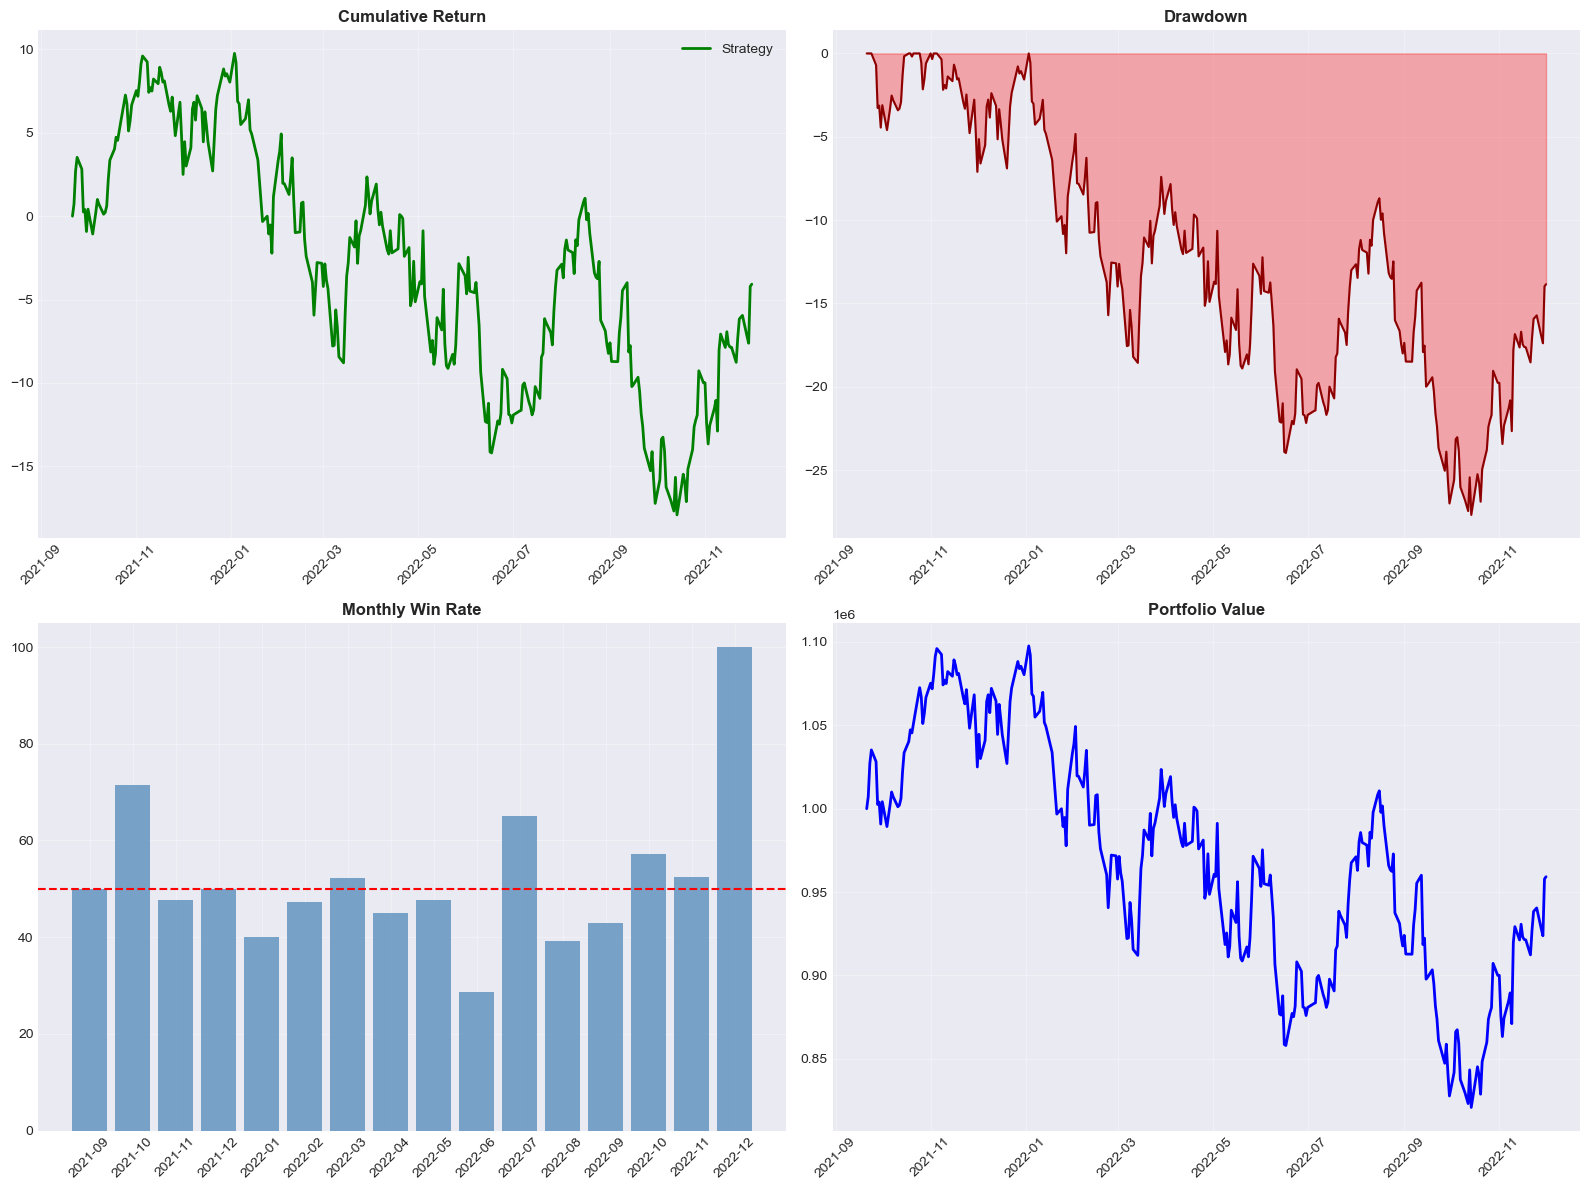


✓ BƯỚC 10 HOÀN THÀNH
✓ PROJECT COMPLETE - All 10 steps executed successfully!


In [11]:
# ============================================================================
# BƯỚC 10: PERFORMANCE EVALUATION
# ============================================================================

print("="*80)
print("BƯỚC 10: PERFORMANCE EVALUATION")
print("="*80)

# Calculate metrics
initial = backtest_results['Portfolio_Value'].iloc[0]
final = backtest_results['Portfolio_Value'].iloc[-1]
total_return = (final / initial) - 1
num_years = (backtest_results['Date'].iloc[-1] - backtest_results['Date'].iloc[0]).days / 365.25
annualized_return = (1 + total_return) ** (1 / num_years) - 1
win_rate = (backtest_results['Portfolio_Return'] > 0).mean()

cumulative = backtest_results['Cumulative_Return']
max_drawdown = (cumulative - cumulative.expanding().max()).min()
sharpe_ratio = (backtest_results['Portfolio_Return'].mean() / backtest_results['Portfolio_Return'].std()) * np.sqrt(252) if backtest_results['Portfolio_Return'].std() > 0 else 0

print(f"\nPerformance Summary:")
print(f"  Total Return:        {100*total_return:.2f}%")
print(f"  Annualized Return:   {100*annualized_return:.2f}%")
print(f"  Win Rate:            {100*win_rate:.2f}%")
print(f"  Maximum Drawdown:    {100*max_drawdown:.2f}%")
print(f"  Sharpe Ratio:        {sharpe_ratio:.4f}")

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].plot(backtest_results['Date'], backtest_results['Cumulative_Return'] * 100, 
               linewidth=2, color='green', label='Strategy')
axes[0, 0].set_title('Cumulative Return', fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

drawdown_pct = (cumulative - cumulative.expanding().max()) * 100
axes[0, 1].fill_between(backtest_results['Date'], drawdown_pct, 0, color='red', alpha=0.3)
axes[0, 1].plot(backtest_results['Date'], drawdown_pct, color='darkred', linewidth=1.5)
axes[0, 1].set_title('Drawdown', fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

monthly_win_rate = backtest_results.groupby(pd.to_datetime(backtest_results['Date']).dt.to_period('M')).apply(
    lambda x: (x['Portfolio_Return'] > 0).mean()
)
axes[1, 0].bar(range(len(monthly_win_rate)), monthly_win_rate.values * 100, color='steelblue', alpha=0.7)
axes[1, 0].axhline(y=50, color='r', linestyle='--')
axes[1, 0].set_title('Monthly Win Rate', fontweight='bold')
axes[1, 0].set_xticks(range(len(monthly_win_rate)))
axes[1, 0].set_xticklabels([str(p) for p in monthly_win_rate.index], rotation=45)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(backtest_results['Date'], backtest_results['Portfolio_Value'], linewidth=2, color='blue')
axes[1, 1].set_title('Portfolio Value', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n{'='*80}\n✓ BƯỚC 10 HOÀN THÀNH\n{'='*80}")
print("✓ PROJECT COMPLETE - All 10 steps executed successfully!")
print("="*80)
